Using device: cuda
Loading: /kaggle/input/speech-emotion-10/data_EmoDB_split.xlsx
Extracting emotion labels from file paths...
Đã tải và xử lý 61 mẫu thử nghiệm từ sheet 'data_test'.
Đã tải và xử lý 474 mẫu từ sheet 'data_train'.
Đã chia sheet 'data_train' thành 379 mẫu training và 95 mẫu validation.
Creating and fitting a new scaler.
Scaler successfully fitted on individual Mel values.
Using provided pre-fitted scaler.
Using provided pre-fitted scaler.

Training sample: 379
Validation sample: 95
Test sample: 61
Emotion classes: 7

Start training...
Epoch 1/50:
   Train Loss: 0.87, Train Acc: 0.31
   Val Loss: 0.77, Val Acc: 0.44, Val UA: 0.37
Saved best model!
Epoch 2/50:
   Train Loss: 0.73, Train Acc: 0.43
   Val Loss: 0.65, Val Acc: 0.49, Val UA: 0.44
Saved best model!
Epoch 3/50:
   Train Loss: 0.65, Train Acc: 0.49
   Val Loss: 0.59, Val Acc: 0.59, Val UA: 0.53
Saved best model!
Epoch 4/50:
   Train Loss: 0.59, Train Acc: 0.55
   Val Loss: 0.55, Val Acc: 0.56, Val UA: 0.52
Epoch 

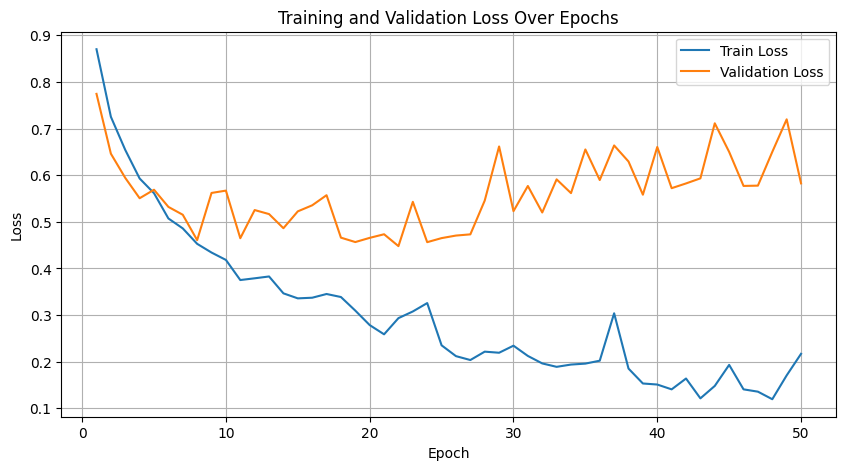

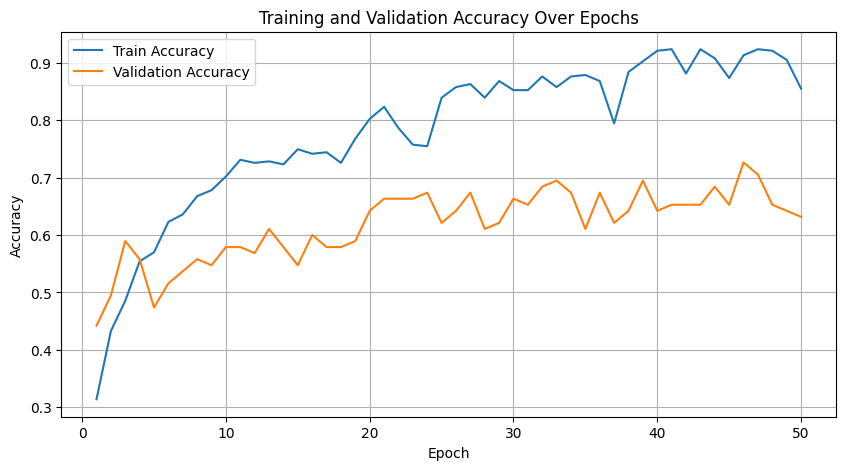


Evaluate the best model on the test set...

Results on test set:
   Test Loss: 0.32
   Test Accuracy (ACC): 0.85
   Test Unweighted Accuracy (UA): 0.81
   Test F1-score (Weighted): 0.85

Classification Report:
              precision    recall  f1-score   support

       Angry       0.95      0.95      0.95        19
       Happy       0.86      0.75      0.80         8
        Fear       0.78      1.00      0.88         7
     Neutral       0.88      0.78      0.82         9
         Sad       1.00      0.80      0.89         5
     Disgust       1.00      0.40      0.57         5
     Boredom       0.67      1.00      0.80         8

    accuracy                           0.85        61
   macro avg       0.87      0.81      0.82        61
weighted avg       0.88      0.85      0.85        61



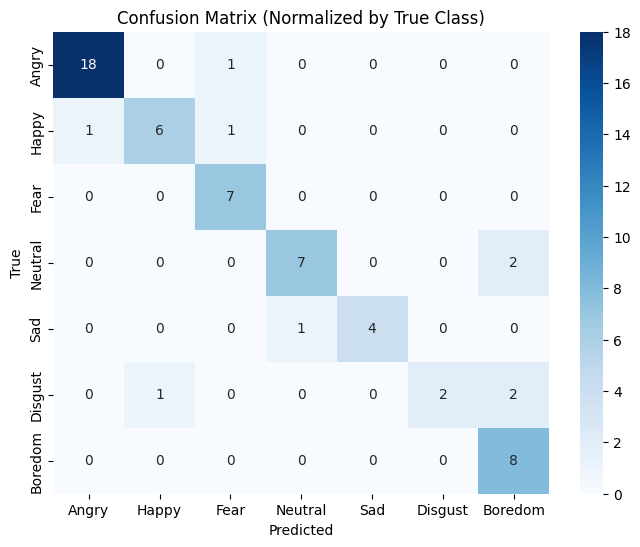

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import random
import soundfile as sf

# --- 1. Cấu hình và Thiết lập Môi trường ---
# setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Cấu hình siêu tham số
SAMPLE_RATE = 16000
N_MELS = 128
MAX_AUDIO_DURATION = 3
MAX_SEQ_LEN = 250
MASK_RATE = 0.15
PI_BALANCE = 0.5

BATCH_SIZE = 16
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

# Cấu hình Transformer
NUM_TRANSFORMER_BLOCKS = 4
EMBED_DIM = N_MELS
NUM_HEADS = 8

# --- 2. Tiền xử lý Dữ liệu và Dataset ---

# Ánh xạ nhãn cảm xúc để nhất quán
EMOTION_TO_INT_EMODB = {
    'Angry': 0,
    'Happy': 1,
    'Fear': 2,
    'Neutral': 3,
    'Sad': 4,
    'Disgust': 5,
    'Boredom': 6
}
INT_TO_EMOTION_EMODB = {v: k for k, v in EMOTION_TO_INT_EMODB.items()}
NUM_EMOTIONS_EMODB = len(EMOTION_TO_INT_EMODB)


class SpeechEmotionDataset(Dataset):
    def __init__(self, audio_paths, labels, sample_rate, n_mels, max_seq_len, transform=None, scaler=None):
        self.audio_paths = audio_paths
        self.labels = labels
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.max_seq_len = max_seq_len
        self.transform = transform
        
        if scaler:
            self.scaler = scaler
            print("Using provided pre-fitted scaler.")
        else:
            self.scaler = StandardScaler()
            print("Creating and fitting a new scaler.")
            self._fit_scaler()

    def _fit_scaler(self):
        all_mel_values = []
        if not self.audio_paths:
            print("Warning: No audio paths provided. Cannot fit scaler.")
            self.scaler.mean_ = np.zeros(1)
            self.scaler.scale_ = np.ones(1)
            return

        sample_indices = random.sample(range(len(self.audio_paths)), min(100, len(self.audio_paths)))
        
        for i in sample_indices:
            try:
                audio, sr = librosa.load(self.audio_paths[i], sr=self.sample_rate)
                mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=self.n_mels)
                mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
                all_mel_values.extend(mel_spectrogram.flatten())
            except Exception as e:
                continue    
        
        if all_mel_values:
            self.scaler.fit(np.array(all_mel_values).reshape(-1, 1))
            print("Scaler successfully fitted on individual Mel values.")
        else:
            print("Warning: Not enough data to fit scaler. Using default StandardScaler.")
            self.scaler.mean_ = np.zeros(1)
            self.scaler.scale_ = np.ones(1)

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = self.labels[idx]

        try:
            audio, sr = librosa.load(audio_path, sr=self.sample_rate)
            
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=self.n_mels)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            if hasattr(self.scaler, 'mean_') and self.scaler.mean_ is not None:
                mel_spectrogram = self.scaler.transform(mel_spectrogram.reshape(-1, 1)).reshape(mel_spectrogram.shape)
            
            if mel_spectrogram.shape[1] < self.max_seq_len:
                pad_width = self.max_seq_len - mel_spectrogram.shape[1]
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, pad_width)), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :self.max_seq_len]
            
            mel_spectrogram = torch.tensor(mel_spectrogram, dtype=torch.float32)

            return mel_spectrogram, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            print(f"Error loading or processing file {audio_path}: {e}")
            return torch.zeros(self.n_mels, self.max_seq_len), torch.tensor(-1, dtype=torch.long)

# --- HÀM ĐÃ ĐƯỢC CẬP NHẬT ---
# --- HÀM ĐÃ ĐƯỢC CẬP NHẬT VỚI CHỨC NĂNG CHẨN ĐOÁN LỖI ---
def load_split_data_from_excel(excel_path, emotion_map, val_split_ratio=0.2):
    """
    Tải dữ liệu từ tệp Excel có 2 sheet: 'data_train' và 'data_test'.
    Mỗi sheet chỉ chứa cột 'filepath'. Nhãn emotion được suy ra từ tên thư mục cha.
    """
    try:
        xls = pd.ExcelFile(excel_path)
        if 'data_train' not in xls.sheet_names or 'data_test' not in xls.sheet_names:
            print("Lỗi: Tệp Excel phải chứa các sheet có tên 'data_train' và 'data_test'.")
            return ([], [], [], [], [], [])
        
        train_val_df = pd.read_excel(xls, sheet_name='data_train')
        test_df = pd.read_excel(xls, sheet_name='data_test')

    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy tệp Excel tại {excel_path}")
        return ([], [], [], [], [], [])

    required_column = 'filepath'
    if required_column not in train_val_df.columns or required_column not in test_df.columns:
        print(f"Lỗi: Cả hai sheet phải chứa cột '{required_column}'")
        return ([], [], [], [], [], [])

    def get_emotion_from_path(path):
        return os.path.basename(os.path.dirname(path))

    print("Extracting emotion labels from file paths...")
    train_val_df['emotion'] = train_val_df['filepath'].apply(get_emotion_from_path)
    test_df['emotion'] = test_df['filepath'].apply(get_emotion_from_path)
    
    # ===== BẮT ĐẦU ĐOẠN CODE CHẨN ĐOÁN LỖI =====
    all_extracted_labels = set(train_val_df['emotion'].unique()) | set(test_df['emotion'].unique())
    defined_labels = set(emotion_map.keys())
    
    mismatched_labels = all_extracted_labels - defined_labels
    
    if mismatched_labels:
        print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
        print("!!! CẢNH BÁO: PHÁT HIỆN CÁC NHÃN KHÔNG KHỚP !!!")
        print(f"!!! Các nhãn sau được trích xuất từ tên thư mục nhưng không có trong từ điển EMOTION_TO_INT_EMODB:")
        for label in mismatched_labels:
            print(f"!!!   - '{label}'")
        print("!!! Vui lòng kiểm tra lại tên thư mục hoặc cập nhật từ điển trong code.")
        print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!\n")
        # Trả về rỗng để ngăn chương trình chạy với lỗi
        return ([], [], [], [], [], [])
    # ===== KẾT THÚC ĐOẠN CODE CHẨN ĐOÁN LỖI =====
    
    # 1. Xử lý tập test
    test_paths = test_df['filepath'].tolist()
    test_labels = test_df['emotion'].map(emotion_map).tolist()
    print(f"Đã tải và xử lý {len(test_paths)} mẫu thử nghiệm từ sheet 'data_test'.")

    # 2. Xử lý và chia tập train/validation
    print(f"Đã tải và xử lý {len(train_val_df)} mẫu từ sheet 'data_train'.")
    if len(train_val_df) == 0:
        print("Cảnh báo: Sheet 'data_train' trống.")
        return ([], [], [], [], test_paths, test_labels)

    X = train_val_df['filepath']
    y = train_val_df['emotion'].map(emotion_map)

    # Nếu không có lỗi, y sẽ không chứa NaN
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        X.to_numpy(), y.to_numpy(),
        test_size=val_split_ratio,
        random_state=SEED,
        stratify=y
    )

    print(f"Đã chia sheet 'data_train' thành {len(train_paths)} mẫu training và {len(val_paths)} mẫu validation.")

    return (
        list(train_paths), list(train_labels),
        list(val_paths), list(val_labels),
        test_paths, test_labels
    )
    

# --- 3. ESERNet Model Architecture ---
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        assert self.head_dim * num_heads == self.embed_dim, "embed_dim must be divisible by num_heads"
        
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, context=None, mask=None):
        if context is None:
            context = query

        batch_size_q, seq_len_q, _ = query.size()
        batch_size_c, seq_len_k, _ = context.size()

        q = self.q_proj(query).reshape(batch_size_q, seq_len_q, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = self.k_proj(context).reshape(batch_size_c, seq_len_k, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        v = self.v_proj(context).reshape(batch_size_c, seq_len_k, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        
        energy = torch.matmul(q, k.transpose(-1, -2)) / (self.head_dim ** 0.5)
        
        if mask is not None:
            mask_expanded = (mask.unsqueeze(1).unsqueeze(2) == 1)
            energy = energy.masked_fill(mask_expanded, float('-inf'))

        attention = F.softmax(energy, dim=-1)
        out = torch.matmul(attention, v)
        out = out.permute(0, 2, 1, 3).reshape(batch_size_q, seq_len_q, self.embed_dim)
        out = self.out_proj(out)
        return out

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = MultiHeadAttention(embed_dim, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        norm_x = self.norm1(x)
        attn_output = self.attention(norm_x, mask=mask)
        x = x + self.dropout1(attn_output)

        norm_x = self.norm2(x)
        ffn_output = self.ffn(norm_x)
        x = x + self.dropout2(ffn_output)
        return x

class WordObjectEncoderStep(nn.Module):
    def __init__(self, embed_dim, num_heads, num_word_tokens, window_size):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_word_tokens = num_word_tokens
        self.window_size = window_size
        self.word_tokens = nn.Parameter(torch.randn(1, num_word_tokens, embed_dim))
        self.word_encoder_mhsa = MultiHeadAttention(embed_dim, num_heads)
        self.object_encoder_mhsa = MultiHeadAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        segment_len = seq_len // self.num_word_tokens
        if segment_len == 0:
             pooled_segments = x.mean(dim=1).unsqueeze(1).repeat(1, self.num_word_tokens, 1)
        else:
            non_overlapping_segments = x[:, :self.num_word_tokens * segment_len].reshape(
                batch_size * self.num_word_tokens, segment_len, self.embed_dim
            )
            pooled_segments = non_overlapping_segments.mean(dim=1).reshape(batch_size, self.num_word_tokens, self.embed_dim)
        
        expanded_tokens = self.word_tokens.expand(batch_size, -1, -1)
        updated_tokens = self.word_encoder_mhsa(query=expanded_tokens, context=pooled_segments)

        x_permuted = x.permute(0, 2, 1)
        if seq_len < self.window_size:
            padding = self.window_size - seq_len
            x_permuted = F.pad(x_permuted, (0, padding))

        overlapping_segments = x_permuted.unfold(dimension=2, size=self.window_size, step=1).permute(0, 2, 3, 1)
        num_windows = overlapping_segments.size(1)
        object_tokens = overlapping_segments[:, :, self.window_size // 2, :]
        context_tokens = updated_tokens.mean(dim=1).unsqueeze(1).repeat(1, num_windows, 1)
        
        attended_features = self.object_encoder_mhsa(query=object_tokens, context=updated_tokens)
        
        final_features = attended_features
        out = self.norm1(final_features)
        out = out + self.ffn(self.norm2(out))
        return out

class CombinedBlock(nn.Module):
    def __init__(self, in_dim, out_dim, pool_size):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(pool_size)
        self.proj = nn.Linear(in_dim, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x):
        x_permuted = x.permute(0, 2, 1)
        pooled = self.pool(x_permuted).permute(0, 2, 1)
        projected = self.proj(pooled)
        normalized = self.norm(projected)
        return normalized

class ESERNet(nn.Module):
    def __init__(self, n_mels, max_seq_len, embed_dim, num_heads, num_transformer_blocks, num_emotions, mask_rate):
        super().__init__()
        self.n_mels = n_mels
        self.max_seq_len = max_seq_len
        self.embed_dim = embed_dim
        self.mask_rate = mask_rate

        self.input_linear = nn.Linear(n_mels, embed_dim) if n_mels != embed_dim else nn.Identity()

        self.mask_embedding_linear = nn.Linear(1, embed_dim)
        self.key_cue_transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, embed_dim * 4) for _ in range(num_transformer_blocks)
        ])
        self.recover_linear = nn.Linear(embed_dim, n_mels)

        self.encoder_step1 = WordObjectEncoderStep(embed_dim, num_heads, num_word_tokens=16, window_size=5)
        pool_size_1 = max(1, int(max_seq_len * 0.5))
        self.combiner1 = CombinedBlock(embed_dim, embed_dim, pool_size_1)
        
        self.encoder_step2 = WordObjectEncoderStep(embed_dim, num_heads, num_word_tokens=8, window_size=7)
        pool_size_2 = max(1, int(pool_size_1 * 0.5))
        self.combiner2 = CombinedBlock(embed_dim, embed_dim, pool_size_2)

        self.encoder_step3 = WordObjectEncoderStep(embed_dim, num_heads, num_word_tokens=4, window_size=9)
        
        self.relationship_transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, embed_dim * 4) for _ in range(num_transformer_blocks)
        ])
        
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, num_emotions)
        )

    def forward(self, x):
        batch_size, _, seq_len = x.size()
        
        x_permuted = x.permute(0, 2, 1)
        x_embed = self.input_linear(x_permuted)

        mask = torch.zeros(batch_size, seq_len, dtype=torch.float32).to(x.device)
        num_masked_tokens = min(seq_len, int(seq_len * self.mask_rate))
        if self.training:
            for i in range(batch_size):
                if num_masked_tokens > 0:
                    indices_to_mask = random.sample(range(seq_len), num_masked_tokens)
                    mask[i, indices_to_mask] = 1.0
        
        s_m = x_embed * (1 - mask).unsqueeze(-1)
        s_prime_key_cue = s_m + self.mask_embedding_linear(mask.unsqueeze(-1))
        for block in self.key_cue_transformer_blocks:
            s_prime_key_cue = block(s_prime_key_cue, mask=mask)
        recovered_spectrogram = self.recover_linear(s_prime_key_cue).permute(0, 2, 1)

        rel_features = self.encoder_step1(x_embed)
        rel_features = self.combiner1(rel_features)
        
        rel_features = self.encoder_step2(rel_features)
        rel_features = self.combiner2(rel_features)

        rel_features = self.encoder_step3(rel_features)

        for block in self.relationship_transformer_blocks:
            rel_features = block(rel_features)
        
        final_pooled_features = rel_features.mean(dim=1)
        logits = self.classifier(final_pooled_features)

        return recovered_spectrogram, logits, mask

# --- 4. Model Training ---
def train_epoch(model, dataloader, optimizer, criterion_L1, criterion_L2, pi_balance, device):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    filtered_batches = []
    for mel_spectrograms, labels in dataloader:
        valid_indices = (labels != -1).nonzero(as_tuple=True)[0]
        if valid_indices.numel() > 0:
            filtered_batches.append((mel_spectrograms[valid_indices], labels[valid_indices]))

    for i, (mel_spectrograms, labels) in enumerate(filtered_batches):
        mel_spectrograms = mel_spectrograms.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        recovered_spectrogram, logits, mask = model(mel_spectrograms)

        mask_expanded_for_mse = mask.unsqueeze(1).repeat(1, N_MELS, 1)
        loss_L1 = criterion_L1(recovered_spectrogram * mask_expanded_for_mse, 
                               mel_spectrograms * mask_expanded_for_mse)
        loss_L2 = criterion_L2(logits, labels)
        loss = (1 - pi_balance) * loss_L1 + pi_balance * loss_L2
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    avg_loss = total_loss / len(filtered_batches) if filtered_batches else 0
    accuracy = correct_predictions / total_samples if total_samples else 0
    return avg_loss, accuracy

def evaluate_model(model, dataloader, criterion_L1, criterion_L2, pi_balance, device, num_emotions):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    filtered_batches = []
    for mel_spectrograms, labels in dataloader:
        valid_indices = (labels != -1).nonzero(as_tuple=True)[0]
        if valid_indices.numel() > 0:
            filtered_batches.append((mel_spectrograms[valid_indices], labels[valid_indices]))

    with torch.no_grad():
        for mel_spectrograms, labels in filtered_batches:
            mel_spectrograms = mel_spectrograms.to(device)
            labels = labels.to(device)

            recovered_spectrogram, logits, mask = model(mel_spectrograms)
            mask_expanded_for_mse = mask.unsqueeze(1).repeat(1, N_MELS, 1)
            loss_L1 = criterion_L1(recovered_spectrogram * mask_expanded_for_mse, 
                                   mel_spectrograms * mask_expanded_for_mse)
            loss_L2 = criterion_L2(logits, labels)
            loss = (1 - pi_balance) * loss_L1 + pi_balance * loss_L2
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_loss = total_loss / len(filtered_batches) if filtered_batches else 0
    accuracy = correct_predictions / total_samples if total_samples else 0
    
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    
    class_accuracies = []
    for i in range(num_emotions):
        class_labels_mask = np.array(all_labels) == i
        if np.sum(class_labels_mask) > 0:
            class_preds_for_class = np.array(all_preds)[class_labels_mask]
            class_correct = np.sum(class_preds_for_class == i)
            class_accuracy = class_correct / np.sum(class_labels_mask)
            class_accuracies.append(class_accuracy)
    ua = np.mean(class_accuracies) if class_accuracies else 0
    per_class_f1_scores = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)[2]
    
    return avg_loss, accuracy, ua, precision, recall, f1, all_labels, all_preds, per_class_f1_scores

# --- 5. Main Function ---
def main(excel_data_path):
    num_emotions = NUM_EMOTIONS_EMODB  
    
    train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = \
        load_split_data_from_excel(excel_data_path, EMOTION_TO_INT_EMODB, val_split_ratio=0.2)

    if not train_paths and not test_paths:
        print("Can not load data from excel file.")
        return

    train_dataset = SpeechEmotionDataset(
        train_paths, train_labels, SAMPLE_RATE, N_MELS, MAX_SEQ_LEN
    )
    
    val_dataset = SpeechEmotionDataset(
        val_paths, val_labels, SAMPLE_RATE, N_MELS, MAX_SEQ_LEN, scaler=train_dataset.scaler
    )
    test_dataset = SpeechEmotionDataset(
        test_paths, test_labels, SAMPLE_RATE, N_MELS, MAX_SEQ_LEN, scaler=train_dataset.scaler
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"\nTraining sample: {len(train_dataset)}")
    print(f"Validation sample: {len(val_dataset)}")
    print(f"Test sample: {len(test_dataset)}")
    print(f"Emotion classes: {num_emotions}")

    model = ESERNet(N_MELS, MAX_SEQ_LEN, EMBED_DIM, NUM_HEADS, NUM_TRANSFORMER_BLOCKS, num_emotions, MASK_RATE).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion_L1 = nn.MSELoss()
    criterion_L2 = nn.CrossEntropyLoss()

    best_val_accuracy = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    print("\nStart training...")
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion_L1, criterion_L2, PI_BALANCE, device)
        
        if len(val_loader) > 0:
            val_loss, val_acc, val_ua, _, _, _, _, _, _ = evaluate_model(model, val_loader, criterion_L1, criterion_L2, PI_BALANCE, device, num_emotions)
        else:
            val_loss, val_acc, val_ua = 0, 0, 0
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
        print(f"   Train Loss: {train_loss:.2f}, Train Acc: {train_acc:.2f}")
        print(f"   Val Loss: {val_loss:.2f}, Val Acc: {val_acc:.2f}, Val UA: {val_ua:.2f}")
        
        if len(val_loader) > 0 and val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            torch.save(model.state_dict(), "best_esernet_model.pth")
            print("Saved best model!")

    print("\nTraining Complete.")

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss')
    plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    if os.path.exists("best_esernet_model.pth"):
        print("\nEvaluate the best model on the test set...")
        model.load_state_dict(torch.load("best_esernet_model.pth"))
        
        if len(test_loader) > 0:
            test_loss, test_acc, test_ua, test_prec, test_rec, test_f1, all_labels, all_preds, _ = evaluate_model(model, test_loader, criterion_L1, criterion_L2, PI_BALANCE, device, num_emotions)
            
            print(f"\nResults on test set:")
            print(f"   Test Loss: {test_loss:.2f}")
            print(f"   Test Accuracy (ACC): {test_acc:.2f}")
            print(f"   Test Unweighted Accuracy (UA): {test_ua:.2f}")
            print(f"   Test F1-score (Weighted): {test_f1:.2f}")

            if all_labels and all_preds:
                target_names = [INT_TO_EMOTION_EMODB[i] for i in sorted(INT_TO_EMOTION_EMODB.keys())]
                report = classification_report(all_labels, all_preds, target_names=target_names, digits=2, zero_division=0)
                print("\nClassification Report:")
                print(report)

                cm = confusion_matrix(all_labels, all_preds)
                #cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
                plt.figure(figsize=(8, 6))
                sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                            xticklabels=target_names, yticklabels=target_names)
                plt.xlabel("Predicted")
                plt.ylabel("True")
                plt.title("Confusion Matrix (Normalized by True Class)")
                plt.show()
        else:
            print("No test set to evaluate.")
    else:
        print("Saved model not found for evaluation.")

# --- 6. Entry Point ---
if __name__ == "__main__":
    # !!! QUAN TRỌNG: THAY ĐỔI ĐƯỜNG DẪN DƯỚI ĐÂY
    # Trỏ đến tệp Excel của bạn. Tệp phải có 2 sheet: 'data_train' và 'data_test'
    # Mỗi sheet chỉ cần chứa một cột 'filepath'.
    EXCEL_DATA_PATH = "/kaggle/input/speech-emotion-10/data_EmoDB_split.xlsx"
    
    print(f"Loading: {EXCEL_DATA_PATH}")
    main(excel_data_path=EXCEL_DATA_PATH)